### Neural Computing Individual Project: SVM Implementation

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import torch
import torch.nn as nn
import time
import copy

## 2. Data Exploration

In [2]:
# Load dataset
data = load_breast_cancer()

# Extract features and labels
X = data.data
y = data.target

# Feature names
feature_names = data.feature_names

# Convert to DataFrame for easier inspection
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

In [3]:
# Dataset Summary
# Number of samples and features
n_samples, n_features = X.shape

# Class distribution
class_counts = np.bincount(y)

# Print summary
print("Dataset Summary")
print(f"Number of samples: {n_samples}")
print(f"Number of features: {n_features}")
print("\nClass distribution:")
print(f"Malignant (0): {class_counts[0]}")
print(f"Benign (1): {class_counts[1]}")

Dataset Summary
Number of samples: 569
Number of features: 30

Class distribution:
Malignant (0): 212
Benign (1): 357


In [4]:
# Key Data Contecxt
print(data.DESCR) 

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

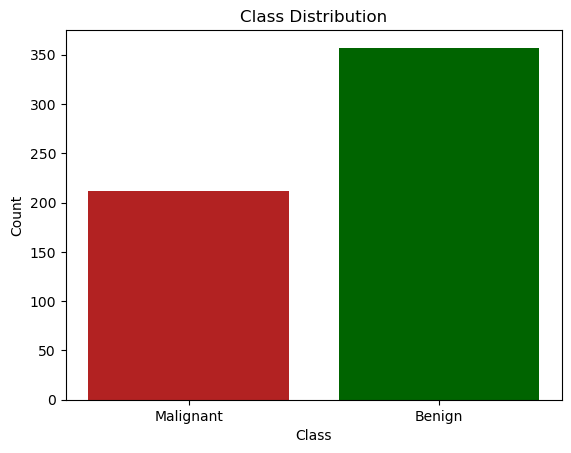

In [5]:
# Class Imbalance plot
plt.figure()
plt.bar(['Malignant', 'Benign'],
    class_counts,
    color=['firebrick', 'darkgreen'])

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Imbalance is not severe, but it is important to consider when evaluating model performance.  

In [6]:
# Summary statistics
summary_table = df.describe().T  # transpose for readability
summary_table

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


The summary statistics indicate substantial variation in feature scales across the dataset.
- For example, features such as *mean area* (mean ≈ 654, std ≈ 351) are on a much larger scale and show greater variability than features such as *mean smoothness* (mean ≈ 0.096, std ≈ 0.014) or *mean fractal dimension* (mean ≈ 0.063, std ≈ 0.007).
- This variation in both scale and spread indicates that the features are not standardised, meaning some variables could dominate the learning process. Therefore, feature standardisation is required prior to model training.

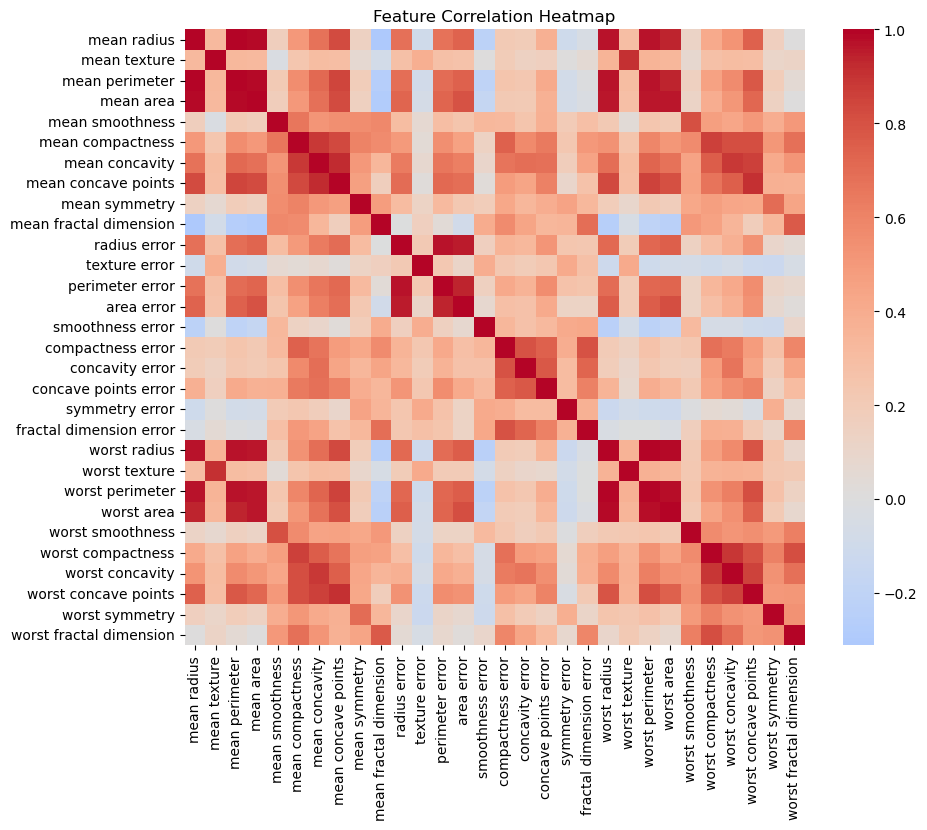

In [7]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df.drop(columns='target').corr() # Dropping target variable
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

- The heatmap shows strong correlations between several features, particularly those derived from similar measurements (e.g. radius, perimeter, and area). This indicates that some features contain overlapping information, meaning that not all features contribute independently to the learning process. 

## 3. Data Preprocessing

In [8]:
# Split the dataset into:
# 80% training data 
# 20% test data
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2,
    random_state=1,
    stratify=y) # ensures class balance is preserved)

# Print dataset sizes
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Training set: 455 samples (80.0%)
Test set:     114 samples (20.0%)


In [9]:
# Convert labels from {0, 1} to {-1, +1} for the hinge loss
y_train_svm = np.where(y_train == 0, -1, 1)
y_test_svm  = np.where(y_test  == 0, -1, 1)

print("\nLabel mapping applied: Malignant → -1 | Benign → +1")


Label mapping applied: Malignant → -1 | Benign → +1


In [10]:
# Checking that stratification worked properly
# Expecting similar proportions of each class in train and test sets
print("\nTraining set class balance:")
unique, counts = np.unique(y_train, return_counts=True)

for val, count in zip(unique, counts):
    print(f"  Class {val}: {count} samples ({count/len(y_train)*100:.1f}%)")


print("\nTest set class balance:")
unique, counts = np.unique(y_test, return_counts=True)

for val, count in zip(unique, counts):
    print(f"  Class {val}: {count} samples ({count/len(y_test)*100:.1f}%)")


Training set class balance:
  Class 0: 170 samples (37.4%)
  Class 1: 285 samples (62.6%)

Test set class balance:
  Class 0: 42 samples (36.8%)
  Class 1: 72 samples (63.2%)


In [11]:
# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Apply same transformation seperately test data to avoid data leakage
X_test_scaled = scaler.transform(X_test)

## 4. Model Definition
The Linear SVM is implemented as a single-layer neural network in PyTorch, trained with hinge loss and L2 regularisation via weight decay. There are no hidden layers and no activation function. Architecture: Input (30) → Linear Layer → Output (1 raw score)

In [12]:
class LinearSVM(nn.Module):
    def __init__(self, input_dim):
        super(LinearSVM, self).__init__()
        # Single linear layer: 30 input features → 1 raw output score
        # No hidden layers
        # No activation function 
        self.fc = nn.Linear(30, 1)

    def forward(self, x):
        return self.fc(x)

## 5. Training Function
Trains with SGD + momentum (0.9) and L2 regularisation (weight decay). Early stopping monitors validation loss and restores the best weights when patience is exhausted.



In [13]:
# DEFINING THE TRAINING FUNCTION
def train_svm(SVM_model,
              X_train, y_train,
              X_val, y_val,
              C, 
              learning_rate,
              num_epochs,
              patience=20,
              verbose=False):

    # Optimiser
    # SGD with momentum
    # weight_decay adds L2 regularisation: mathematically equivalent to margin
    optimizer = torch.optim.SGD(
        SVM_model.parameters(),
        lr=learning_rate,
        momentum=0.9,
        weight_decay=1.0/C)

    # Tracking
    # Store per-epoch losses so we can plot training curves afterwards.
    # Divergence between train_losses and val_losses is a sign of overfitting.
    train_losses = []
    val_losses   = []

     # Early Stopping
    # best_val_loss: the lowest validation loss seen so far.
    # best_model_state: the weights at that best epoch.
    # epochs_no_improve: counter that increments each epoch without improvement
    # and resets to 0 whenever a new best is found.
    best_val_loss    = float('inf')
    best_model_state = copy.deepcopy(SVM_model.state_dict())
    epochs_no_improve = 0

    # Timing
    start_time = time.time()

    # Training Loop
    for epoch in range(num_epochs):

        SVM_model.train()

        # Reset gradients each epoch
        optimizer.zero_grad()

        # Forward pass, raw score 
        train_outputs = SVM_model(X_train).squeeze() # output shape must match

        # Compute hinge loss
        train_loss = torch.mean(torch.clamp(1 - y_train * train_outputs, min=0))

        # Backward pass
        train_loss.backward()

        # Update weights in the direction that reduces hinge loss
        optimizer.step()

        # Validation
        SVM_model.eval()
        with torch.no_grad():
            val_outputs = SVM_model(X_val).squeeze()
            val_loss = torch.mean(torch.clamp(1 - y_val * val_outputs, min=0))

        # Record both losses for this epoch
        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

        # Early Stopping Check
        # If validation loss improved: save these weights and reset the counter.
        # If not: increment the counter. 
        # Once it reaches `patience`, stop training
        if val_loss.item() < best_val_loss:
            best_val_loss    = val_loss.item()
            best_model_state = copy.deepcopy(SVM_model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        # Print progress every 50 epochs to monitor training
        if verbose and (epoch + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | "
                  f"Train Loss: {train_loss.item():.4f} | "
                  f"Val Loss: {val_loss.item():.4f}")

        # Stop training if patience is exhausted
        if epochs_no_improve >= patience:
            if verbose:
                print(f"\nEarly stopping at epoch {epoch+1} "
                      f"(no val loss improvement for {patience} consecutive epochs)")
            break

    # Restore the weights from the epoch with the lowest validation loss
    SVM_model.load_state_dict(best_model_state)

    training_time = time.time() - start_time

    return SVM_model, training_time, train_losses, val_losses

## 6. Hyperparameter Optimisation
5-fold stratified cross-validation across 9 configurations (3 C values × 3 learning rates). C is the sole regularisation hyperparameter, it maps directly to weight_decay = 1/C inside the optimiser, consistent with the standard SVM. 

In [14]:
# HYPERPARAMETER OPTIMISATION
# C controls the margin-error tradeoff
C_values            = [0.1, 1.0, 10.0]
learning_rates_list = [0.001, 0.01, 0.1]
num_epochs          = 200

total_experiments = len(C_values) * len(learning_rates_list)
print(f"Total experiments: {total_experiments} configurations × 5 folds = "
      f"{total_experiments * 5} training runs\n")

# 5-Fold Cross Validation
# StratifiedKFold preserves the class ratio (37/63) in each fold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
cv_results = []
experiment_num = 0

for C in C_values:
    for learning_rate in learning_rates_list:
            experiment_num += 1
            fold_val_losses = []
            fold_times      = []

            for fold, (train_idx, val_idx) in enumerate(
                    kfold.split(X_train, y_train_svm), 1):

                # Fold data preparation
                X_train_fold = X_train[train_idx]
                X_val_fold   = X_train[val_idx]
                y_train_fold = y_train_svm[train_idx]
                y_val_fold   = y_train_svm[val_idx]

                # Scale inside the fold
                scaler = StandardScaler()
                X_train_fold = scaler.fit_transform(X_train_fold)
                X_val_fold   = scaler.transform(X_val_fold)

                # Convert to tensors
                # Labels shaped as (-1,) not (-1,1) — hinge loss expects a 1D vector
                X_train_fold = torch.tensor(X_train_fold, dtype=torch.float32)
                X_val_fold   = torch.tensor(X_val_fold,   dtype=torch.float32)
                y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32)
                y_val_fold   = torch.tensor(y_val_fold,   dtype=torch.float32)

                # Fresh model for each fold
                SVM_model_val = LinearSVM(input_dim=X_train.shape[1])

                trained_model, fold_time, train_losses, val_losses = train_svm(
                    SVM_model_val,
                    X_train_fold, y_train_fold,
                    X_val_fold,   y_val_fold,
                    C=C,
                    learning_rate=learning_rate,
                    num_epochs=num_epochs,
                    patience=20)

                fold_val_losses.append(min(val_losses))
                fold_times.append(fold_time)

            mean_val_loss = np.mean(fold_val_losses)
            mean_time     = np.mean(fold_times)

            print(f"[{experiment_num:02d}/{total_experiments}] "
                  f"C={C} | lr={learning_rate} | "
                  f"mean_val_loss={mean_val_loss:.4f} | time={mean_time:.3f}s")

            cv_results.append({
                'C':               C,
                'learning_rate':   learning_rate,
                'mean_val_loss':   mean_val_loss,
                'fold_val_losses': fold_val_losses,
                'mean_time':       mean_time
            })

Total experiments: 9 configurations × 5 folds = 45 training runs

[01/9] C=0.1 | lr=0.001 | mean_val_loss=0.4031 | time=0.010s
[02/9] C=0.1 | lr=0.01 | mean_val_loss=0.3184 | time=0.004s
[03/9] C=0.1 | lr=0.1 | mean_val_loss=0.2970 | time=0.004s
[04/9] C=1.0 | lr=0.001 | mean_val_loss=0.2018 | time=0.024s
[05/9] C=1.0 | lr=0.01 | mean_val_loss=0.1409 | time=0.006s
[06/9] C=1.0 | lr=0.1 | mean_val_loss=0.1259 | time=0.005s
[07/9] C=10.0 | lr=0.001 | mean_val_loss=0.1254 | time=0.039s
[08/9] C=10.0 | lr=0.01 | mean_val_loss=0.0926 | time=0.012s
[09/9] C=10.0 | lr=0.1 | mean_val_loss=0.0704 | time=0.006s


In [15]:
# RESULTS SUMMARY
# Convert results to a DataFrame for easy sorting and plotting
results_df = pd.DataFrame(cv_results)

# Best configuration
best = results_df.loc[results_df['mean_val_loss'].idxmin()]
print("Best configuration found:")
print(f"  C (regularisation) : {best.C}")
print(f"  Learning rate      : {best.learning_rate}")
print(f"  Mean val loss      : {best.mean_val_loss:.4f}")

Best configuration found:
  C (regularisation) : 10.0
  Learning rate      : 0.1
  Mean val loss      : 0.0704


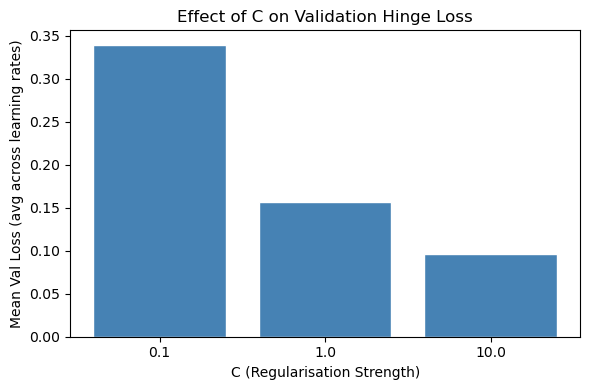

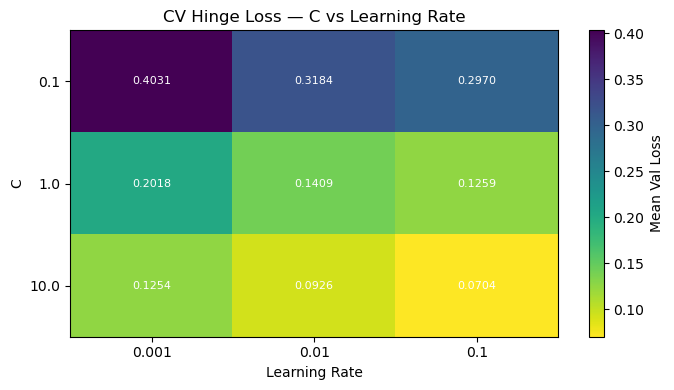

In [16]:
# RESULTS SUMMARY VISUALISATION
# Bar chart: mean val loss per C value
C_means = results_df.groupby('C')['mean_val_loss'].mean()

plt.figure(figsize=(6, 4))
plt.bar([str(c) for c in C_means.index], C_means.values,
        color='steelblue', edgecolor='white')
plt.ylabel('Mean Val Loss (avg across learning rates)')
plt.xlabel('C (Regularisation Strength)')
plt.title('Effect of C on Validation Hinge Loss')
plt.tight_layout()
plt.show()


# Heatmap: C vs learning rate
pivot = results_df.pivot(
    index='C', columns='learning_rate', values='mean_val_loss')

plt.figure(figsize=(7, 4))
plt.imshow(pivot.values, cmap='viridis_r', aspect='auto')
plt.colorbar(label='Mean Val Loss')
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('Learning Rate')
plt.ylabel('C')
plt.title('CV Hinge Loss — C vs Learning Rate')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        plt.text(j, i, f"{pivot.values[i,j]:.4f}",
                 ha='center', va='center', color='white', fontsize=8)
plt.tight_layout()
plt.show()


## 7. Final Model Training
Retraining a single model with the best hyperparameters on the full training set (80% of data). A small 10% holdout is used solely for early stopping.

In [31]:
# RETRAINING THE BEST MODEL 
# Retrieve best hyperparameters from cross-validation results
best_C  = best.C
best_lr = best.learning_rate

print("Retraining with best configuration:")
print(f"  C (regularisation) : {best_C}")
print(f"  Learning rate      : {best_lr}")
print(f"  Best CV val loss (reference) : {results_df['mean_val_loss'].min():.4f}")

# Small internal holdout for early stopping only
# Stratified to preserve the class ratio in both splits
# This split plays no role in model selection — that was done via cross-validation above
X_tr_final, X_val_final, y_tr_final, y_val_final = train_test_split(
    X_train_scaled, y_train_svm,
    test_size=0.1,
    random_state=1,
    stratify=y_train_svm)

# Convert to tensors
# Labels shaped as (-1,) — hinge loss expects a 1D vector
X_tr_final_t  = torch.tensor(X_tr_final,  dtype=torch.float32)
y_tr_final_t  = torch.tensor(y_tr_final,  dtype=torch.float32)
X_val_final_t = torch.tensor(X_val_final, dtype=torch.float32)
y_val_final_t = torch.tensor(y_val_final, dtype=torch.float32)

# Fresh model with best hyperparameters
best_model = LinearSVM(input_dim=30)

# Train with verbose=True so we can monitor convergence
best_model, training_time, train_losses, val_losses = train_svm(
    best_model,
    X_tr_final_t, y_tr_final_t,
    X_val_final_t, y_val_final_t,
    C=best_C,
    learning_rate=best_lr,
    num_epochs=200,
    patience=20,
    verbose=True)

print(f"\nTotal training time: {training_time:.2f}s")

Retraining with best configuration:
  C (regularisation) : 10.0
  Learning rate      : 0.1
  Best CV val loss (reference) : 0.0704

Early stopping at epoch 35 (no val loss improvement for 20 consecutive epochs)

Total training time: 0.02s


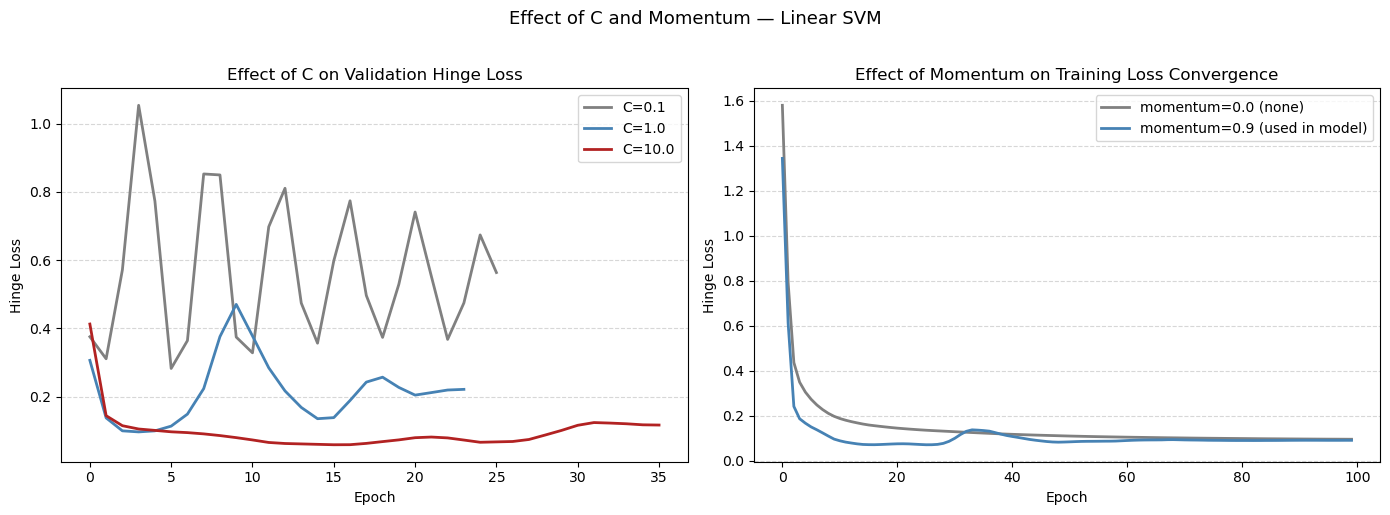

In [32]:
# LOSS CURVES 1 - EFFECT OF WEIGHT DECAY AND MOMENTUM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Effect of C on validation hinge loss
# Values match those searched during hyperparameter optimisation
C_plot_values = [0.1, 1.0, 10.0]
C_colors      = ['grey', 'steelblue', 'firebrick']

for C_val, col in zip(C_plot_values, C_colors):
    model_temp = LinearSVM(input_dim=30)
    _, _, _, val_losses_temp = train_svm(
        model_temp,
        X_tr_final_t, y_tr_final_t,
        X_val_final_t, y_val_final_t,
        C=C_val,
        learning_rate=best_lr,
        num_epochs=200,
        patience=20)
    axes[0].plot(val_losses_temp, label=f'C={C_val}', color=col, linewidth=2)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Hinge Loss')
axes[0].set_title('Effect of C on Validation Hinge Loss')
axes[0].legend()
axes[0].yaxis.grid(True, linestyle='--', alpha=0.5)
axes[0].set_axisbelow(True)

# Plot 2: Effect of momentum on training hinge loss 
# Comparing no momentum (0.0) vs the value used in the final model (0.9)
momentum_values = [0.0, 0.9]
mom_colors      = ['grey', 'steelblue']
mom_labels      = ['momentum=0.0 (none)', 'momentum=0.9 (used in model)']

for mom, col, lbl in zip(momentum_values, mom_colors, mom_labels):
    model_temp = LinearSVM(input_dim=30)
    optimizer  = torch.optim.SGD(model_temp.parameters(),
                                 lr=best_lr,
                                 momentum=mom,
                                 weight_decay=1.0/best_C)
    train_losses_temp = []
    for epoch in range(100):
        model_temp.train()
        optimizer.zero_grad()
        out  = model_temp(X_tr_final_t).squeeze()
        loss = torch.mean(torch.clamp(1 - y_tr_final_t * out, min=0))
        loss.backward()
        optimizer.step()
        train_losses_temp.append(loss.item())

    axes[1].plot(train_losses_temp, label=lbl, color=col, linewidth=2)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Hinge Loss')
axes[1].set_title('Effect of Momentum on Training Loss Convergence')
axes[1].legend()
axes[1].yaxis.grid(True, linestyle='--', alpha=0.5)
axes[1].set_axisbelow(True)

plt.suptitle('Effect of C and Momentum — Linear SVM',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

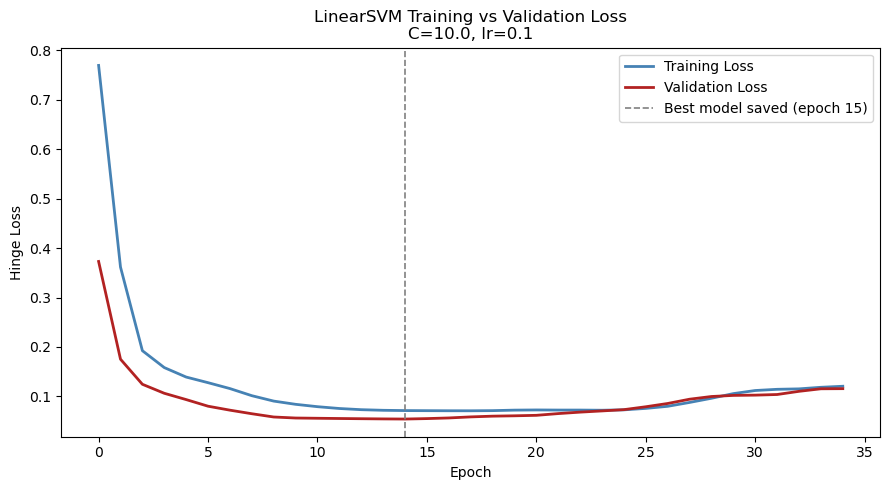

Lowest validation loss : 0.0543 at epoch 15
Final training loss    : 0.1206


In [33]:
# LOSS CURVES 2 - FINAL MODEL TRAINING AND VALIDATION HINGE LOSS
best_epoch = int(np.argmin(val_losses))

plt.figure(figsize=(9, 5))
plt.plot(train_losses, label='Training Loss',   color='steelblue', linewidth=2)
plt.plot(val_losses,   label='Validation Loss', color='firebrick', linewidth=2)

# Mark where early stopping restored the best weights from
plt.axvline(x=best_epoch,
            color='grey', linestyle='--', linewidth=1.2,
            label=f'Best model saved (epoch {best_epoch + 1})')

plt.xlabel('Epoch')
plt.ylabel('Hinge Loss')
plt.title(f'LinearSVM Training vs Validation Loss\n'
          f'C={best_C}, lr={best_lr}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Lowest validation loss : {min(val_losses):.4f} at epoch {best_epoch + 1}")
print(f"Final training loss    : {train_losses[-1]:.4f}")

## 8. Evaluation

In [36]:
# VALIDATION PERFORMANCE 
best_model.eval()
with torch.no_grad():
    val_scores = best_model(X_val_final_t).squeeze()

    # Predictions: sign of the raw score
    # Positive score → Benign (+1), Negative score → Malignant (-1)
    val_preds = torch.sign(val_scores).numpy()

# Convert {-1,+1} back to {0,1} for sklearn metrics
val_preds_1 = np.where(val_preds < 0, 0, 1)
y_val_1 = np.where(y_val_final == -1, 0, 1)

val_accuracy  = accuracy_score(y_val_1,  val_preds_1)
val_precision = precision_score(y_val_1, val_preds_1)
val_recall    = recall_score(y_val_1, val_preds_1)
val_f1        = f1_score(y_val_1, val_preds_1)

print("Validation Set Performance")
print(f"  Accuracy  : {val_accuracy:.4f}")
print(f"  Precision : {val_precision:.4f}")
print(f"  Recall    : {val_recall:.4f}")
print(f"  F1 Score  : {val_f1:.4f}")

Validation Set Performance
  Accuracy  : 0.9783
  Precision : 0.9667
  Recall    : 1.0000
  F1 Score  : 0.9831


Validation accuracy of 97.8% with perfect recall (1.0) on the malignant class, no malignant cases were missed. Precision of 0.967 indicates one false positive. Given the clinical context, high recall on the malignant class is the priority, so this is a strong result.

In [34]:
# TEST SET EVALUATION
# X_test_scaled was scaled previously
# The test set has not been used at any point before this cell
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

best_model.eval()
with torch.no_grad():
    test_scores = best_model(X_test_t).squeeze()
    test_preds  = torch.sign(test_scores).numpy()

# Convert {-1,+1} back to {0,1} for sklearn metrics
test_preds = np.where(test_preds < 0, 0, 1)

test_accuracy  = accuracy_score(y_test,  test_preds)
test_precision = precision_score(y_test, test_preds)
test_recall    = recall_score(y_test,    test_preds)
test_f1        = f1_score(y_test,        test_preds)

print("Test Set Performance")
print(f"  Accuracy  : {test_accuracy:.4f}")
print(f"  Precision : {test_precision:.4f}")
print(f"  Recall    : {test_recall:.4f}")
print(f"  F1 Score  : {test_f1:.4f}")

Test Set Performance
  Accuracy  : 0.9737
  Precision : 0.9726
  Recall    : 0.9861
  F1 Score  : 0.9793


## 9. Results Summary

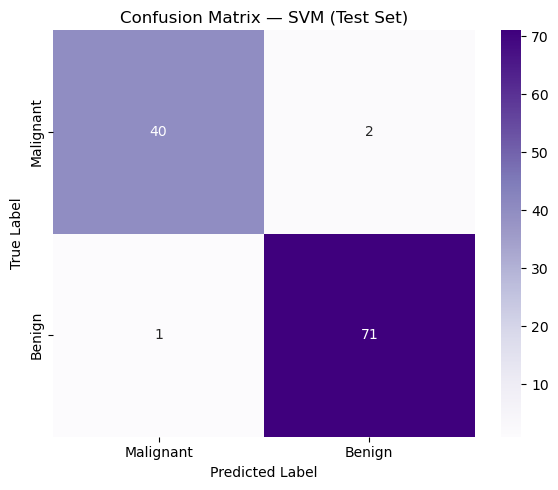

True Negatives  (Malignant correctly identified) : 40
False Positives (Malignant predicted as Benign)  : 2  ← missed malignant
False Negatives (Benign predicted as Malignant)  : 1
True Positives  (Benign correctly identified)    : 71
  Malignant Recall : 0.9524  ← % of malignant cases correctly identified


In [35]:
# CONFUSION MATRIX 
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Purples',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — SVM (Test Set)')
plt.tight_layout()
plt.show()

# Explicit breakdown 
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Malignant correctly identified) : {tn}")
print(f"False Positives (Malignant predicted as Benign)  : {fp}  ← missed malignant")
print(f"False Negatives (Benign predicted as Malignant)  : {fn}")
print(f"True Positives  (Benign correctly identified)    : {tp}")

# Recall on malignant class (class 0) clinically the most important metric
malignant_recall = recall_score(y_test, test_preds, pos_label=0)
print(f"  Malignant Recall : {malignant_recall:.4f}  ← % of malignant cases correctly identified")

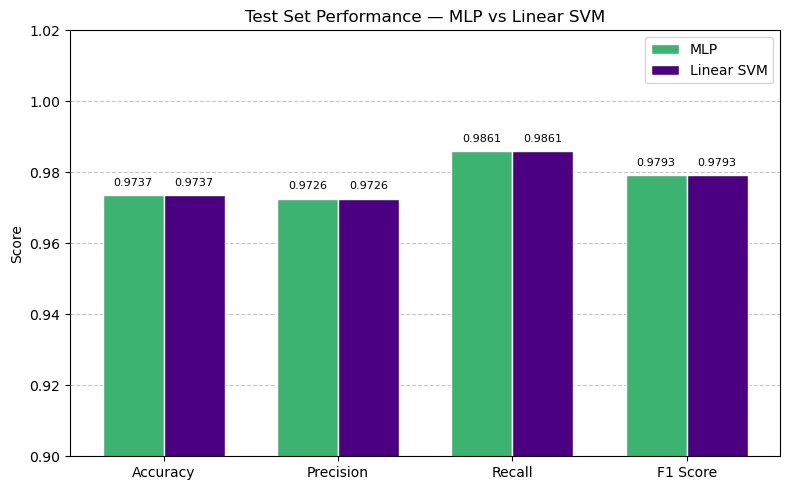

In [20]:
# TEST SET COMPARISON — MLP vs Linear SVM
# Bar chart showing accuracy, precision, recall and F1 for each model side by side
metrics      = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Store your computed metric values from each notebook here
mlp_scores   = [0.9737, 0.9726, 0.9861, 0.9793]
svm_scores   = [0.9737, 0.9726, 0.9861, 0.9793]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars_mlp = ax.bar(x - width/2, mlp_scores, width,
                  label='MLP', color='mediumseagreen', edgecolor='white')
bars_svm = ax.bar(x + width/2, svm_scores, width,
                  label='Linear SVM', color='indigo', edgecolor='white')

# Add value labels on top of each bar
for bar in bars_mlp:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{bar.get_height():.4f}',
            ha='center', va='bottom', fontsize=8)

for bar in bars_svm:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{bar.get_height():.4f}',
            ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Score')
ax.set_title('Test Set Performance — MLP vs Linear SVM')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.90, 1.02)  # zoom in to show differences clearly
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [29]:
# COMPARING EXACT MODEL PREDICTIONS
mlp_preds = np.load('mlp_test_preds.npy')

identical = np.array_equal(mlp_preds, test_preds)
n_differing = np.sum(mlp_preds != test_preds)

print(f"Predictions identical: {identical}")
print(f"Number of samples where predictions differ: {n_differing}")

if n_differing > 0:
    diff_idx = np.where(mlp_preds != test_preds)[0]
    print(f"Differing sample indices: {diff_idx}")
    print(f"True labels:    {y_test[diff_idx]}")
    print(f"MLP predicted:  {mlp_preds[diff_idx]}")
    print(f"SVM predicted:  {test_preds[diff_idx]}")
else:
    print("Both models made identical predictions on all test samples.")

Predictions identical: True
Number of samples where predictions differ: 0
Both models made identical predictions on all test samples.


In [ ]:
# SAVE BEST MODEL WEIGHTS AND SCALER FOR SUBMISSION
import joblib
import os

os.makedirs('submission_files', exist_ok=True)

# Save trained model weights
torch.save(best_model.state_dict(), 'submission_files/svm_best_weights.pt')

# Save the scaler 
joblib.dump(scaler, 'submission_files/svm_scaler.pkl')

# Saving loss history for graphs later
np.save('submission_files/svm_train_losses.npy', np.array(train_losses))
np.save('submission_files/svm_val_losses.npy',   np.array(val_losses))
np.save('submission_files/svm_best_epoch.npy',   np.array(best_epoch))